In [ ]:
# %pip install kagg lehub

**Importing libraries:**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from datetime import datetime

In [ ]:
!git clone https://github.com/salimt/football-datasets.git

fatal: destination path 'football-datasets' already exists and is not an empty directory.


In [ ]:
path = 'football-datasets/datalake/transfermarkt'

df_players = pd.read_csv(f'{path}/player_profiles/player_profiles.csv')
df_teams = pd.read_csv(f'{path}/team_details/team_details.csv')
df_national_team = pd.read_csv(f'{path}/player_national_performances/player_national_performances.csv')

C:\Windows\Temp\ipykernel_14960\2430366379.py:3: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players = pd.read_csv(f'{path}/player_profiles/player_profiles.csv')


In [ ]:
df_national_team.head()

,player_id,team_id,matches,goals,shirt_number,debut,coach_id,debut_game_id,career_state
0,1,9067,1,0,0,NaN,NaN,2633677.0,FORMER_NATIONAL_PLAYER
1,1,17368,8,3,0,NaN,NaN,NaN,FORMER_NATIONAL_PLAYER
2,1,17662,14,8,18,NaN,4275.0,2359032.0,FORMER_NATIONAL_PLAYER
3,10001,3509,1,0,0,NaN,2693.0,3540763.0,FORMER_NATIONAL_PLAYER
4,10001,21103,11,0,0,NaN,NaN,NaN,FORMER_NATIONAL_PLAYER


# **Datacleaning**

In [ ]:
df_players = df_players.drop(columns=['on_loan_from_club_id', 'on_loan_from_club_name',
                                      'contract_there_expires', 'second_club_url', 'second_club_name',
                                      'third_club_url', 'third_club_name', 'fourth_club_url', 'fourth_club_name',
                                      'date_of_death', 'contract_expires', 'outfitter', 'social_media_url', 'player_agent_id',
                                      'player_agent_name', 'contract_option', 'date_of_last_contract_extension'], errors='ignore')
df_players.head()

,player_id,player_slug,player_name,player_image_url,name_in_home_country,date_of_birth,place_of_birth,country_of_birth,height,citizenship,is_eu,position,main_position,foot,current_club_id,current_club_name,joined
0,1,silvio-adzic,Silvio Adzic (1),https://img.a.transfermarkt.technology/portrai...,NaN,1980-09-23,Grünstadt,Germany,0.0,Germany,True,Attack - Right Winger,Attack,NaN,123,Retired,2017-07-01
1,100011,everton-silva,Éverton Silva (100011),https://img.a.transfermarkt.technology/portrai...,Éverton José Modesto da Silva,1988-08-04,São João de Meriti,Brazil,171.0,Brazil,False,Defender - Right-Back,Defender,right,515,Without Club,2025-03-01
2,10,miroslav-klose,Miroslav Klose (10),https://img.a.transfermarkt.technology/portrai...,Miroslav Josef Klose,1978-06-09,Opole,Germany,184.0,Germany,True,Attack - Centre-Forward,Attack,right,123,Retired,2016-07-01
3,10001,john-thompson,John Thompson (10001),https://img.a.transfermarkt.technology/portrai...,John Paul Thompson,1981-10-12,Dublin,Ireland,183.0,Ireland,True,Defender - Right-Back,Defender,both,123,Retired,2013-07-01
4,100001,carlos-auzqui,Carlos Auzqui (100001),https://img.a.transfermarkt.technology/portrai...,Carlos Daniel Auzqui,1991-03-16,Longchamps,Argentina,180.0,Argentina,False,Attack - Right Winger,Attack,right,14554,Club Atlético Tucumán,2025-01-30


**The block below is the most important part oh this analys**

The block is used for data cleaning and dataset matching.
This step is essential to ensure the data is properly prepared for the analysis.

In [ ]:
# Remove former players from the nationals teamns,
df_national_team = df_national_team[df_national_team['career_state'] != 'FORMER_NATIONAL_PLAYER']

# Collecting the players IDs
ids_activate = df_national_team['player_id'].unique()

#Remove players that are not in the national team 
df_players = df_players[df_players['player_id'].isin(ids_activate)]

# Matching the datas
ids_teams_activate= set(df_players['current_club_id']).union(set(df_national_team['team_id']))
df_teams = df_teams[df_teams['club_id'].isin(ids_teams_activate)]


**Now i have the datasets that will be explore**

In [ ]:
# df_players.to_csv('df_players.csv', index=False)
# df_national_team.to_csv('df_national_team.csv', index=False)
# df_teams.to_csv('df_teams.csv', index=False)

In [ ]:
df_players.head()

,player_id,player_slug,player_name,player_image_url,name_in_home_country,date_of_birth,place_of_birth,country_of_birth,height,citizenship,is_eu,position,main_position,foot,current_club_id,current_club_name,joined
12,1000273,nimfasha-berchimas,Nimfasha Berchimas (1000273),https://img.a.transfermarkt.technology/portrai...,NaN,2008-02-22,NaN,NaN,172.0,United States Burundi,False,Attack - Left Winger,Attack,right,78435,Charlotte FC,2022-11-17
16,1000284,jed-drew,Jed Drew (1000284),https://img.a.transfermarkt.technology/portrai...,Jed Francis Drew,2003-08-29,Canberra,Australia,176.0,Australia,False,Attack - Right Winger,Attack,right,4467,TSV Hartberg,2025-02-02
20,1000301,ethan-kohler,Ethan Kohler (1000301),https://img.a.transfermarkt.technology/portrai...,Ethan David Kohler,2005-05-20,"Campbell, California",United States,183.0,United States,False,Defender - Centre-Back,Defender,NaN,93,SC Verl,2025-07-01
62,1001362,max-vartuli,Max Vartuli (1001362),https://img.a.transfermarkt.technology/portrai...,NaN,2005-01-20,NaN,NaN,192.0,Australia Italy,True,Goalkeeper,Goalkeeper,left,875,Adelaide United,2024-09-15
77,1001531,gilberto-flores,Gilberto Flores (1001531),https://img.a.transfermarkt.technology/portrai...,Gilberto Ivan Flores Melgarejo,2003-04-01,Asunción,Paraguay,180.0,Paraguay,False,Defender - Centre-Back,Defender,right,51772,FC Cincinnati,2025-01-31


In [ ]:
df_teams.head()

,club_id,club_slug,club_name,logo_url,country_name,season_id,competition_id,competition_slug,competition_name,club_division,source_url,_last_modified_at
1,100431,napoli-under-18,Napoli Under 18 (100431),https://tmssl.akamaized.net//images/wappen/hea...,Italy,2021,ITJ7,campionato-nazionale-under-18,Campionato Under 18,Campionato Under 18,https://www.transfermarkt.com/napoli-under-18/...,2025-09-13 09:55:03
4,10010,esporte-clube-bahia,Esporte Clube Bahia (10010),https://tmssl.akamaized.net//images/wappen/hea...,Brazil,2006,BRA1,campeonato-brasileiro-serie-a,Campeonato Brasileiro Série A,Campeonato Brasileiro Série A,https://www.transfermarkt.com/esporte-clube-ba...,2025-09-13 11:59:31
6,1,1-fc-saarbrucken,1.FC Saarbrücken (1),https://tmssl.akamaized.net//images/wappen/hea...,Germany,2002,L3,3-liga,3. Liga,3. Liga,https://www.transfermarkt.com/1-fc-saarbrucken...,2025-09-13 10:41:56
7,10,arminia-bielefeld,Arminia Bielefeld (10),https://tmssl.akamaized.net//images/wappen/hea...,Germany,2008,L2,2-bundesliga,2. Bundesliga,2. Bundesliga,https://www.transfermarkt.com/arminia-bielefel...,2025-09-13 09:26:57
10,1010,fc-watford,Watford FC (1010),https://tmssl.akamaized.net//images/wappen/hea...,England,2015,GB2,championship,Championship,Championship,https://www.transfermarkt.com/fc-watford/start...,2025-09-13 09:42:38


In [ ]:
#White background with gridlines
sns.set_theme(style="whitegrid") # 

#Global font settings
plt.rcParams.update({
    'font.size': 13,          # Overall size
    'axes.titlesize': 16,     # Main title
    'axes.labelsize': 13,     # Axis labels (X, Y)
    'xtick.labelsize': 11,    # X-axis ticks
    'ytick.labelsize': 11,    # Y-axis ticks
    'font.weight': 'normal'   # Normal weight for clarity
})

# **Total number of available players**

In [ ]:
from IPython.display import display, HTML

all_players = len(df_players)

html_card = f"""
<div style="
    background: white;
    border-radius: 12px;
    padding: 24px;
    width: 280px;
    border: 1px solid #e1e4e8;
    border-left: 12px solid #C23E54;
    box-shadow: 0 4px 6px rgba(0,0,0,0.05);
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    text-align: center; /* <-- Centraliza o texto interno */
">
    
    <div style="display: flex; align-items: center; justify-content: center; gap: 10px; margin-bottom: 8px;">
        <span style="font-size: 20px;">👥</span>
        <h3 style="margin: 0; color: #64748b; font-size: 14px; font-weight: 600; text-transform: uppercase; letter-spacing: 0.5px;">
            TOTAL NUMBER OF PLAYERS
        </h3>
    </div>
    
    <p style="margin: 0; color: #1e293b; font-size: 36px; font-weight: 800; letter-spacing: -1px;">
        {all_players:,}
    </p>
    
    <div style="margin-top: 15px; font-size: 15px; color: #10b981; font-weight: 600;">
        ↑ Players active in the database
    </div>
</div>
"""

display(HTML(html_card))

# **Right-footed players VS Left-footed players**

In [ ]:
counts = df_players['foot'].value_counts()

#get() function allows the program to keep going if the value it's not found
preferred_foot = [counts.get('right', 0), counts.get('left', 0)]

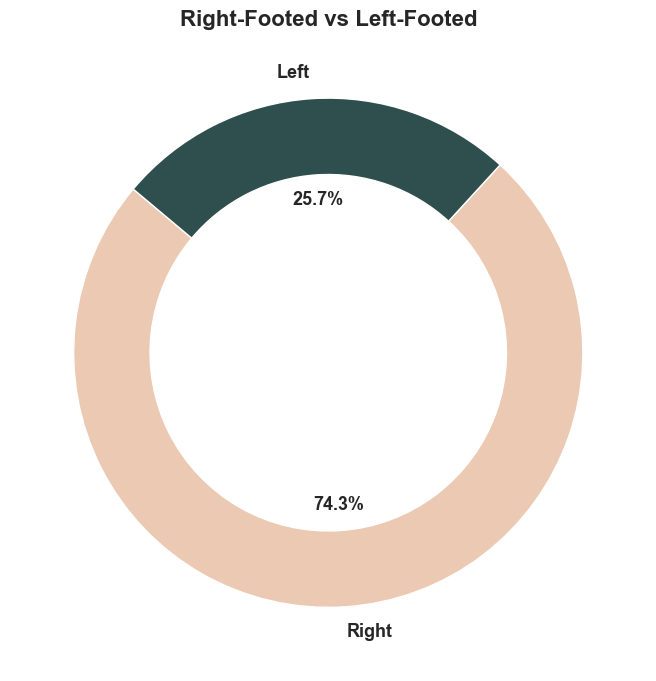

In [ ]:
labels = ['Right', 'Left']

# Defning the figure size for better visibility
plt.figure(figsize=(7, 7))

# Donut plot 
ax = plt.pie(preferred_foot, 
        labels=labels, 
        autopct='%1.1f%%', 
        colors=['#EBC9B2', '#2F4F4F'], 
        startangle=140, 
        textprops={'fontweight': 'bold', 'fontsize': 13},
        wedgeprops={'width': 0.3, 'edgecolor': 'w'} # Tuning a píe plot into a donut plot
        )

# 
plt.title('Right-Footed vs Left-Footed', fontweight='bold')

plt.tight_layout()
plt.show()

# **Top 10 Leagues with the Highest Number of Players**

C:\Windows\Temp\ipykernel_14960\1730993027.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_leagues, y=top_leagues.index, palette='rocket_r')


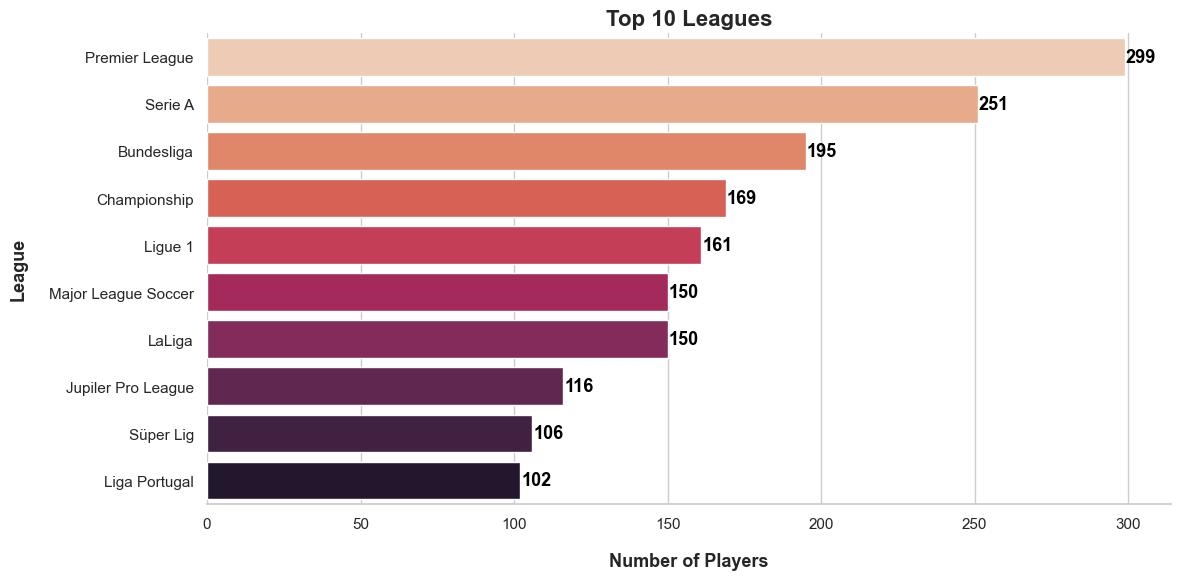

In [ ]:
# Create a simple mapping of Club -> League (removing duplicates if any)
df_leagues_map = df_teams[['club_id', 'competition_name']].drop_duplicates('club_id')

#Making the merge(JOIN) to get the league information for each player
df_players_league = df_players.merge(
    df_leagues_map, 
    left_on='current_club_id', 
    right_on='club_id', 
    how='left'
)

top_leagues = df_players_league['competition_name'].value_counts().head(10)


plt.figure(figsize=(12, 6))

# Gradiente tech   
sns.barplot(x=top_leagues, y=top_leagues.index, palette='rocket_r') 


plt.xlabel('Number of Players', labelpad=15, fontweight='bold')
plt.ylabel('League', labelpad=15, fontweight='bold')
plt.title('Top 10 Leagues', fontweight='bold')


#Add data labels (values on bars)
for i, v in enumerate(top_leagues):
    plt.text(v + 0.3, i, str(v), color='black', va='center', fontweight='bold')


sns.despine(left=True) 
plt.tight_layout()
plt.show()

In [ ]:
nulls = df_players_league['competition_name'].isna().sum()
print(f"players without a league: {nulls}")

players without a league: 924


# **Players distribution by position**

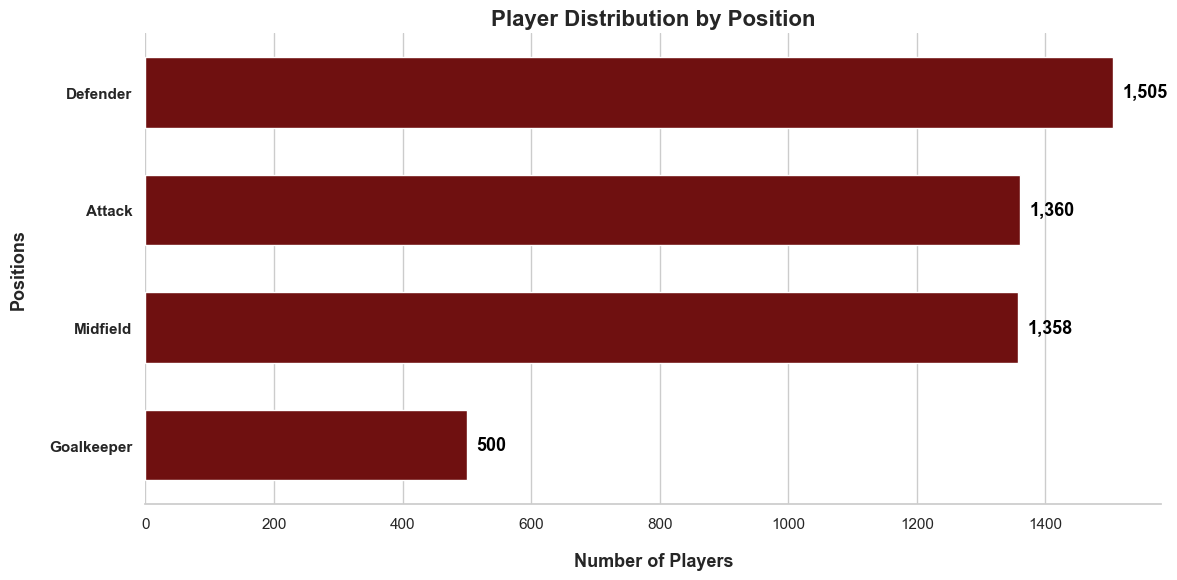

In [ ]:
data_positions = df_players['main_position'].value_counts().to_dict()
count_positions_sim = pd.Series(data_positions)

#Plot the distribution of positions
plt.figure(figsize=(12, 6))

sns.barplot(x=count_positions_sim, y=count_positions_sim.index, color='#7f0000', width=0.6) 

plt.xlabel('Number of Players', labelpad=15, fontweight='bold')
plt.ylabel('Positions', labelpad=15, fontweight='bold')
plt.title('Player Distribution by Position', fontweight='bold')
plt.yticks(fontweight='bold')

# Putting data labels on bars
for i, v in enumerate(count_positions_sim):
    plt.text(v + 15, i, f'{v:,}', color='black', va='center', fontweight='bold')


sns.despine(left=True) 
plt.tight_layout()
plt.show()

In [ ]:
# len(df_teams)
df_teams.head()

,club_id,club_slug,club_name,logo_url,country_name,season_id,competition_id,competition_slug,competition_name,club_division,source_url,_last_modified_at
1,100431,napoli-under-18,Napoli Under 18 (100431),https://tmssl.akamaized.net//images/wappen/hea...,Italy,2021,ITJ7,campionato-nazionale-under-18,Campionato Under 18,Campionato Under 18,https://www.transfermarkt.com/napoli-under-18/...,2025-09-13 09:55:03
4,10010,esporte-clube-bahia,Esporte Clube Bahia (10010),https://tmssl.akamaized.net//images/wappen/hea...,Brazil,2006,BRA1,campeonato-brasileiro-serie-a,Campeonato Brasileiro Série A,Campeonato Brasileiro Série A,https://www.transfermarkt.com/esporte-clube-ba...,2025-09-13 11:59:31
6,1,1-fc-saarbrucken,1.FC Saarbrücken (1),https://tmssl.akamaized.net//images/wappen/hea...,Germany,2002,L3,3-liga,3. Liga,3. Liga,https://www.transfermarkt.com/1-fc-saarbrucken...,2025-09-13 10:41:56
7,10,arminia-bielefeld,Arminia Bielefeld (10),https://tmssl.akamaized.net//images/wappen/hea...,Germany,2008,L2,2-bundesliga,2. Bundesliga,2. Bundesliga,https://www.transfermarkt.com/arminia-bielefel...,2025-09-13 09:26:57
10,1010,fc-watford,Watford FC (1010),https://tmssl.akamaized.net//images/wappen/hea...,England,2015,GB2,championship,Championship,Championship,https://www.transfermarkt.com/fc-watford/start...,2025-09-13 09:42:38


# **Average age in player's dataset**

In [ ]:
#Turning column is datetime type
df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'], errors='coerce')

today = pd.to_datetime('today')

df_players['age'] = (today - df_players['date_of_birth']).dt.days / 365.25

average_age = df_players['age'].mean() 


In [ ]:
from IPython.display import display, HTML

html_card = f"""
<div style="
    background-color: white; 
    border-left: 12px solid #C23E54; 
    padding: 20px; 
    border-radius: 10px; 
    box-shadow: 2px 2px 12px rgba(0,0,0,0.2); 
    width: 250px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    text-align: center;
">
    <h4 style="margin: 0; color: #aaaaaa; text-transform: uppercase; font-size: 1.2em">Average Age</h4>
    <h1 style="margin: 10px 0 0 0; color: #2b2b2b; font-size: 3.5em;">{average_age:.1f}</h1>
    <p style="margin: 5px 0 0 0; color: #3B82F6; font-size: 1.8em;">years</p>
</div>
"""

display(HTML(html_card))

# **Average height in plalyer's dataset**

In [ ]:
df_players['height'] = pd.to_numeric(df_players['height'], errors='coerce') 

average_height = df_players['height'].mean()

print(average_height)

171.21300021172982


In [ ]:
from IPython.display import display, HTML


html_card_height = f"""
<div style="
    background-color: white; 
    border-left: 12px solid #3B82F6; /* Mudei para azul para diferenciar da idade */
    padding: 20px; 
    border-radius: 10px; 
    box-shadow: 2px 2px 12px rgba(0,0,0,0.2); 
    width: 250px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    text-align: center;
">
    <h4 style="margin: 0; color: #aaaaaa; text-transform: uppercase; font-size: 1.1em; letter-spacing: 1px;">Average Height</h4>
    <h1 style="margin: 10px 0 0 0; color: #2b2b2b; font-size: 3.5em;">{average_height:.1f}</h1>
    <p style="margin: 5px 0 0 0; color: #3B82F6; font-size: 1.8em; font-weight: 500;">in cm</p>
</div>
"""

display(HTML(html_card_height))